In [1]:
# защита от падения ядра IPython
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from src.data_preprocessing import (
    read_oscilloscope_data,
    segment_signal,
    perform_fft_on_segments,
    plot_random_segments,
    plot_manual_fft_as_full_spectrogram,
    plot_full_scipy_spectrogram,
    plot_spectrogram_samples,
    spectrogram_samples_from_file,
    spectrogram_samples_manual,
    spectrogram_samples_using_scipy,
    numpy_to_pillow,
    scipy_to_pillow
)

Считаем сигнал из файла.

In [3]:
df = read_oscilloscope_data(
    file_path='../data/raw/0702 без перекосов фаза A.txt',
    output_path='../data/processed/Anomalous.csv'
)

healthy_signal = df['Data'].to_numpy()
healthy_signal_mean = np.mean(healthy_signal)
healthy_signal -= healthy_signal_mean

Отрисуем часть сигнала.

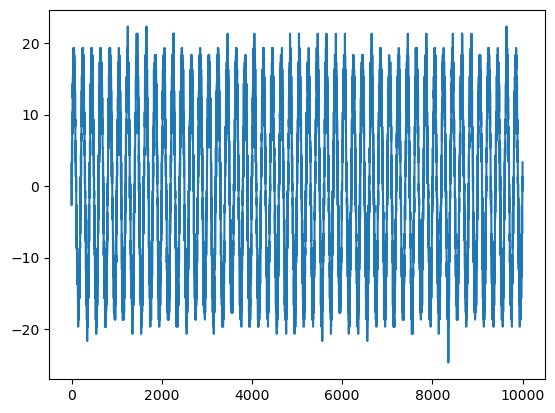

In [4]:
n = 10000
plt.plot(list(range(n)), healthy_signal[:n])
plt.show()

In [5]:
segments = segment_signal(healthy_signal, segment_length=10000, step=20, apply_window='blackman')

In [6]:
len(segments)

4501

Случайные сегменты сигнала после применения оконной функции.

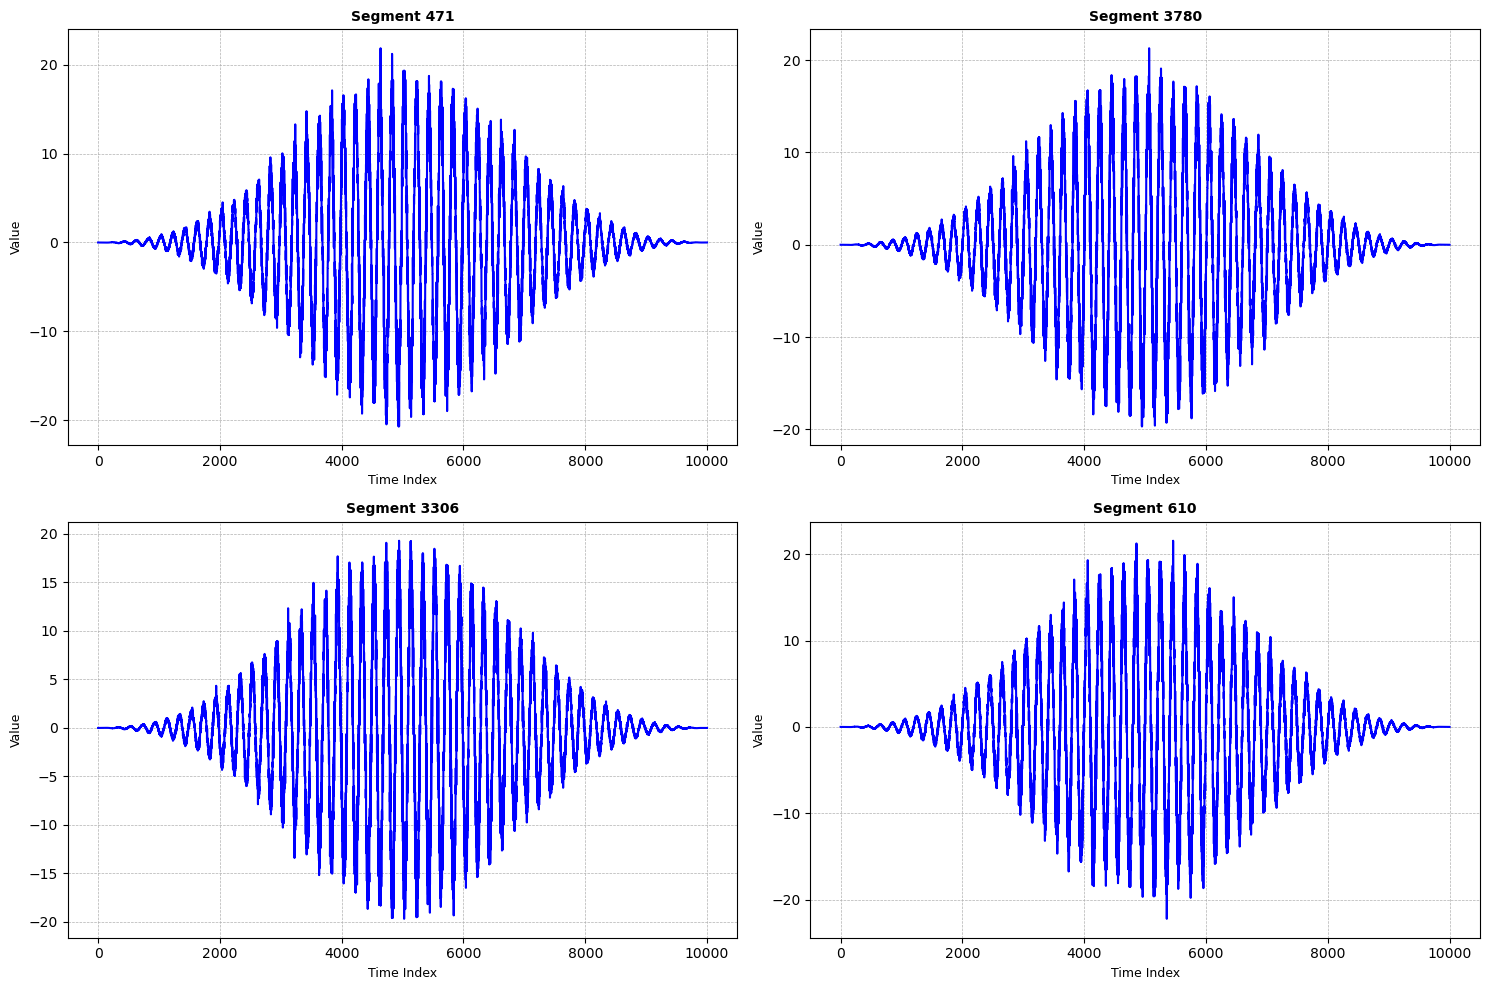

In [7]:
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [8]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

In [9]:
def plot_single_segment_with_uncertainty(fft_segments, x_values=None, max_points=1000, n_std=2, title="Spectrum with Uncertainty",
                                         axis_labels=None, highlight_freqs=None, method='closest'):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std

    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = signal.resample(spectrum_mean, max_points)
        spectrum_std = signal.resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = signal.resample(x_values, max_points)
            else:
                x_values = signal.resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )

    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')

    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig, ax

Усредненный спектр.

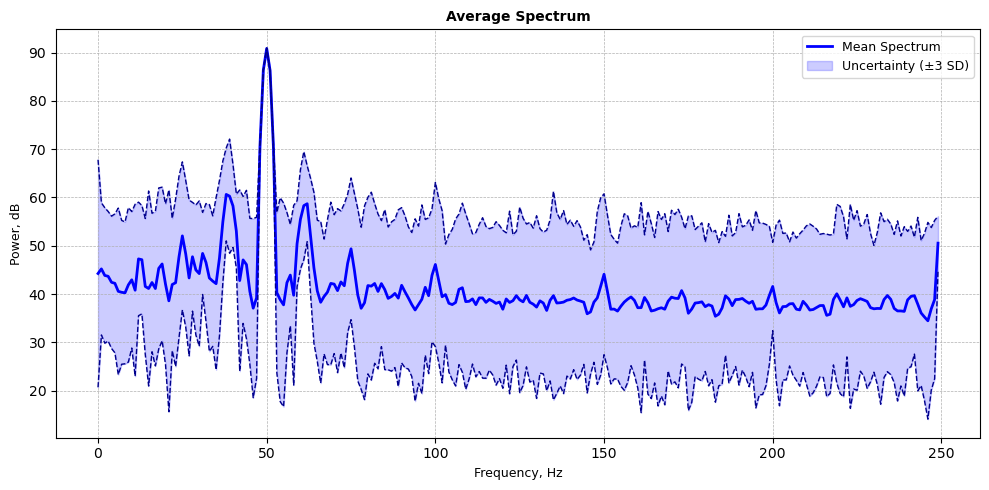

In [10]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

Преобразуем полученные FFT-сегменты в спектрограмму.

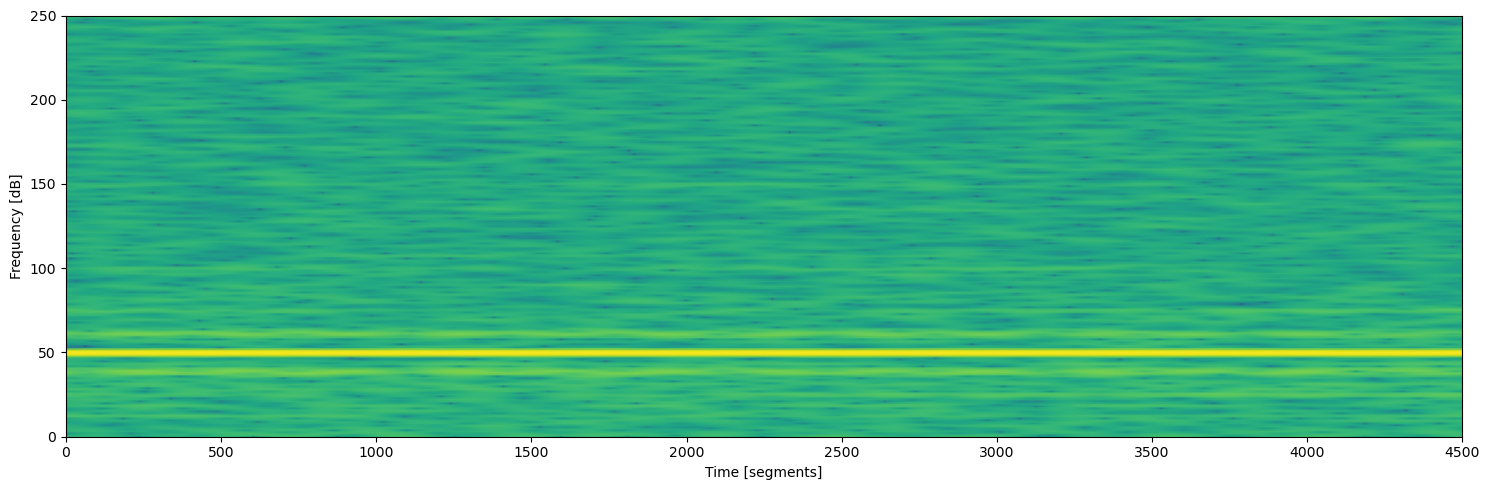

In [11]:
plot_manual_fft_as_full_spectrogram(fft_segments, freqs)

Сравним со спектрограммой, полученной при помощи scipy.signal.spectrogram.

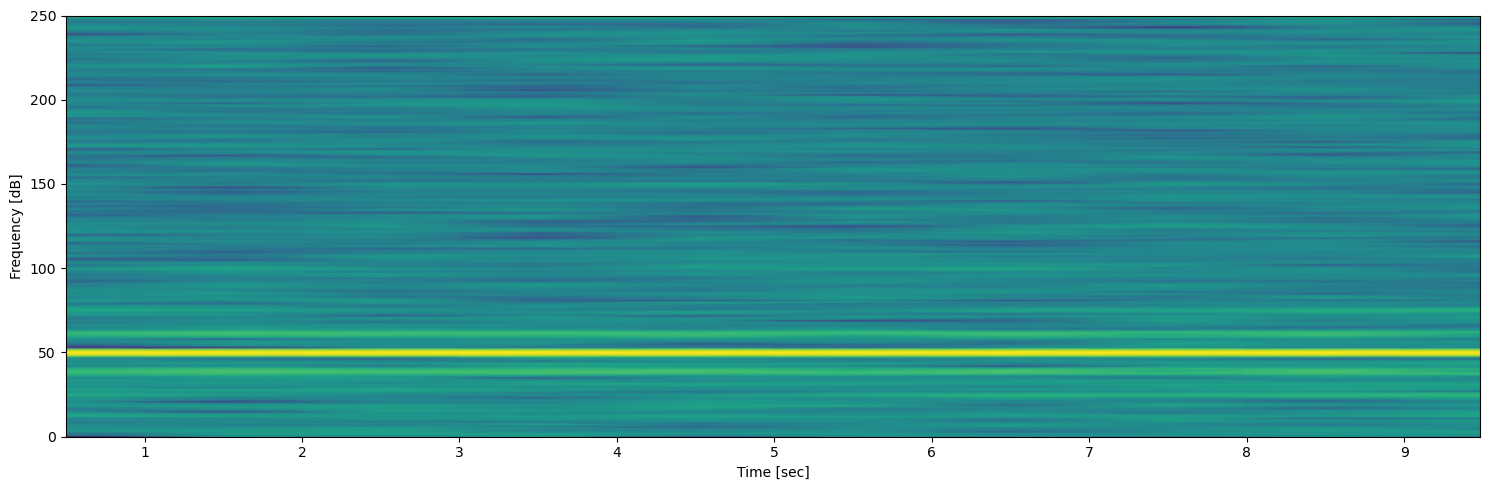

In [12]:
plot_full_scipy_spectrogram(healthy_signal)

Спектрограммы случайных сегментов сигнала заданной длины.

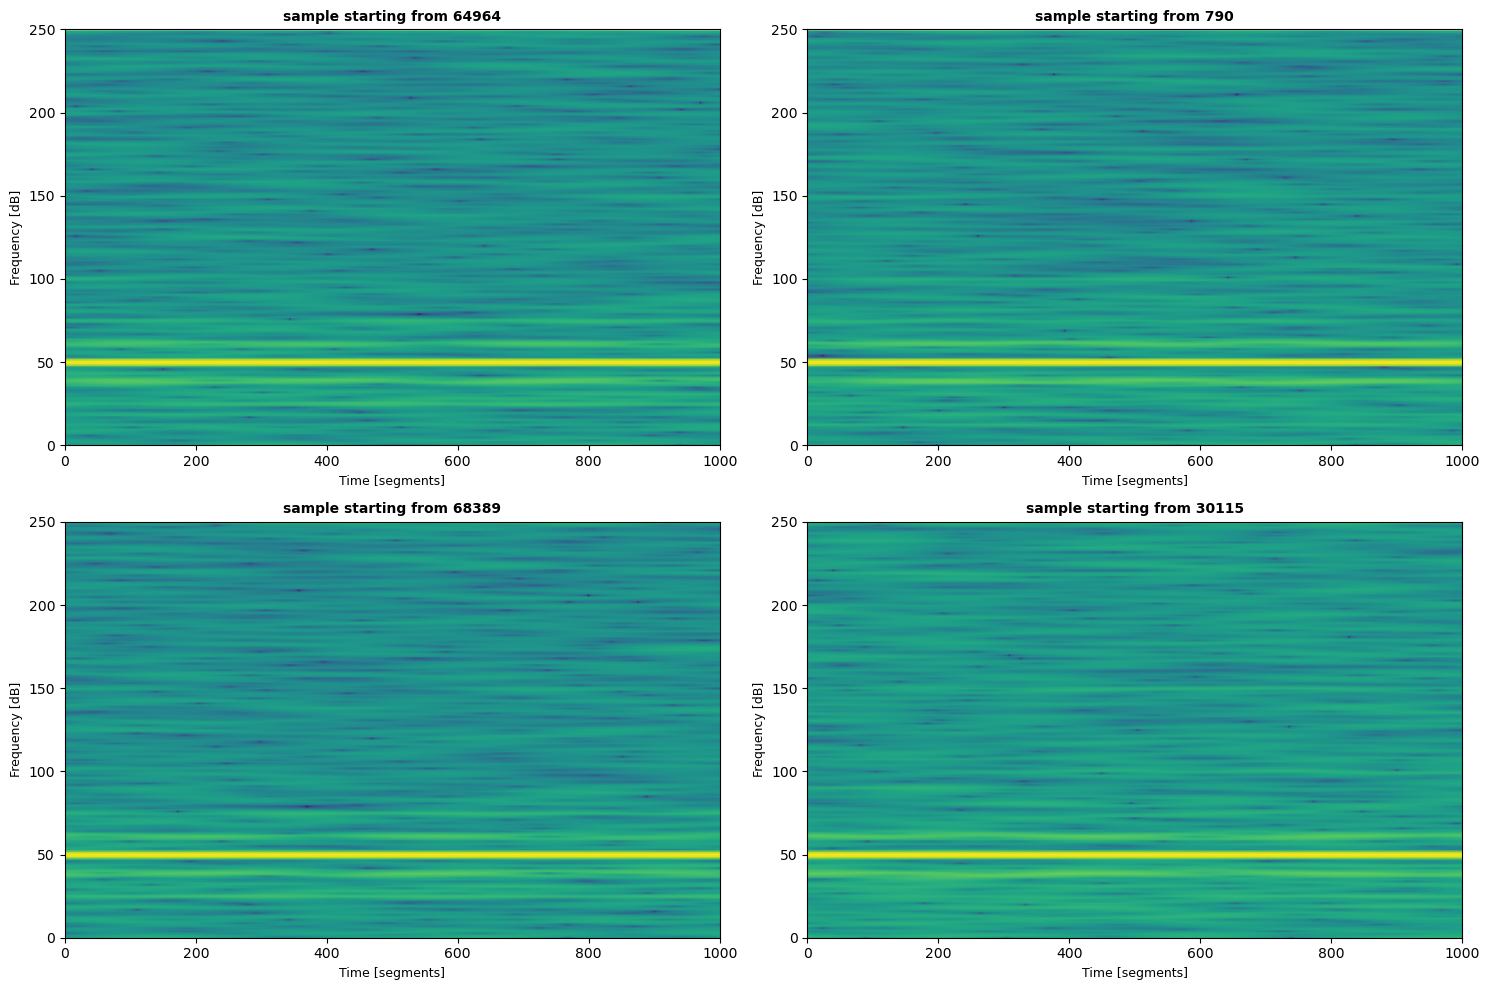

In [13]:
signal_samples = spectrogram_samples_manual(healthy_signal, 3, 4)
plot_spectrogram_samples(signal_samples, ('Time [segments]', 'Frequency [dB]'))
plt.show()

Считаем еще один сигнал из файла.

In [14]:
df = read_oscilloscope_data(
    file_path='../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    output_path='../data/processed/Anomalous.csv'
    )

fault_signal = df['Data'].to_numpy()
fault_signal_mean = np.mean(fault_signal)
fault_signal -= fault_signal_mean

In [15]:
segments = segment_signal(fault_signal, segment_length=10000, step=20, apply_window='blackman')

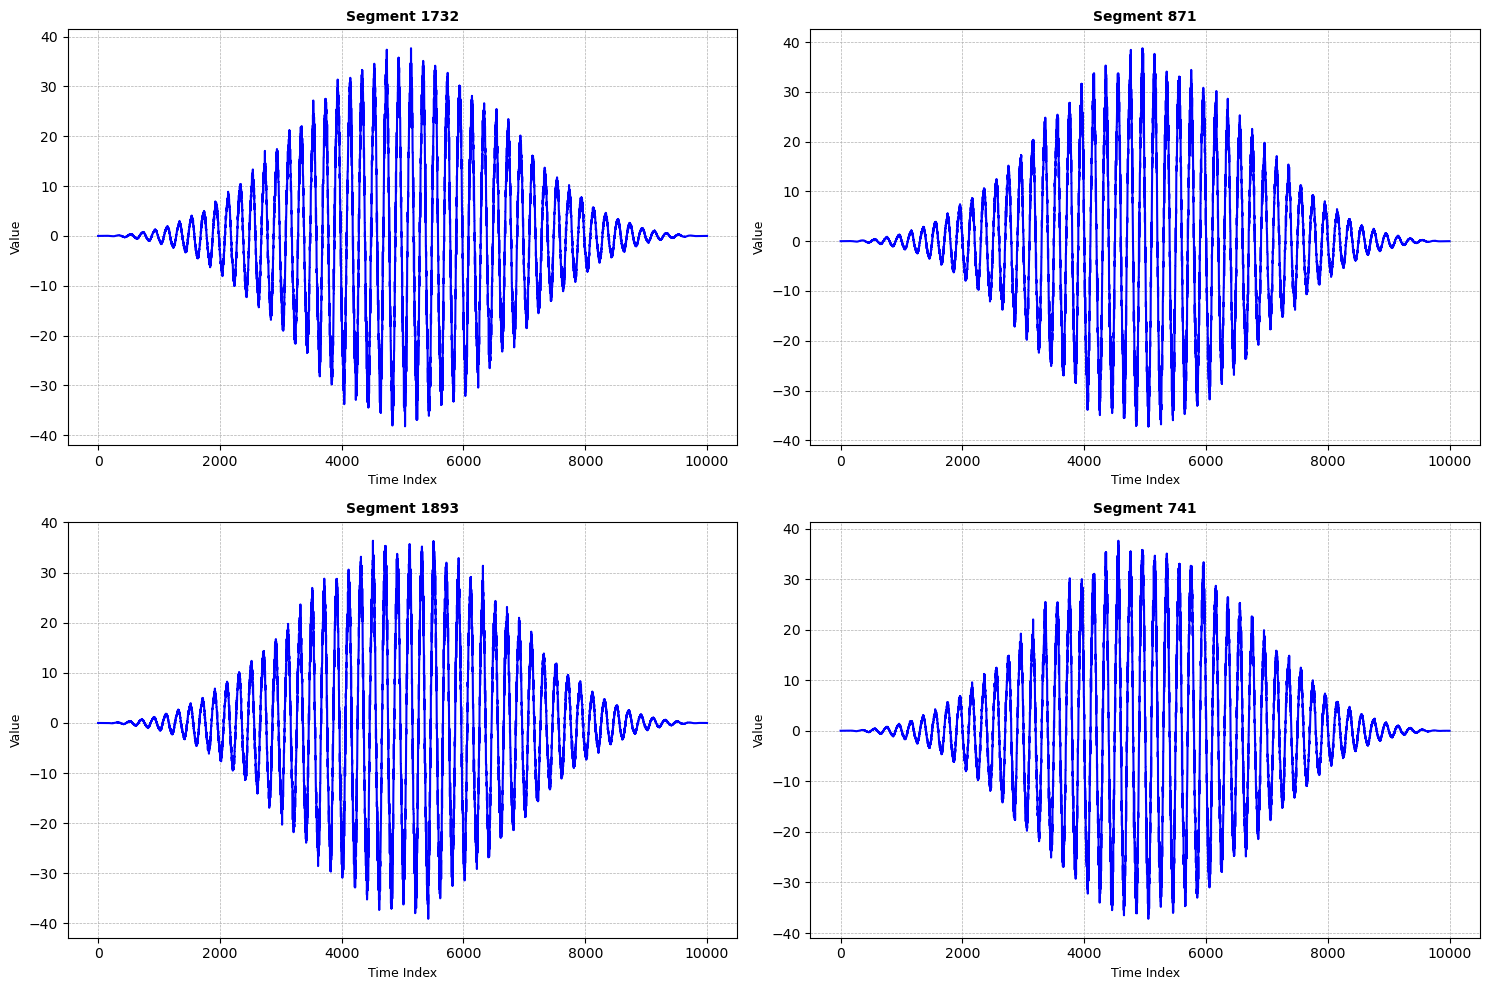

In [16]:
plot_random_segments(segments, num_segments=4, max_points=None, axis_labels=('Time Index', 'Value'))
plt.show()

In [17]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

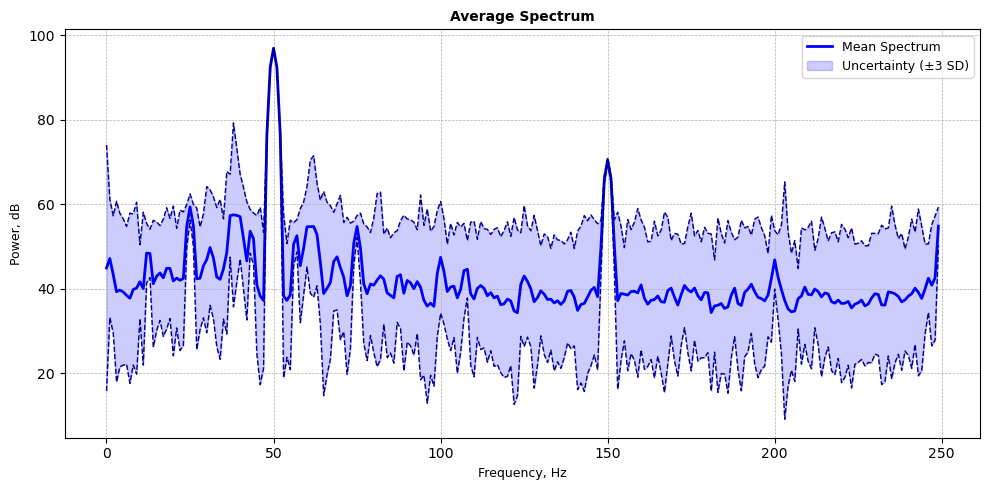

In [18]:
plot_single_segment_with_uncertainty(fft_segments, x_values=freqs, n_std=3, title='Average Spectrum')
plt.show()

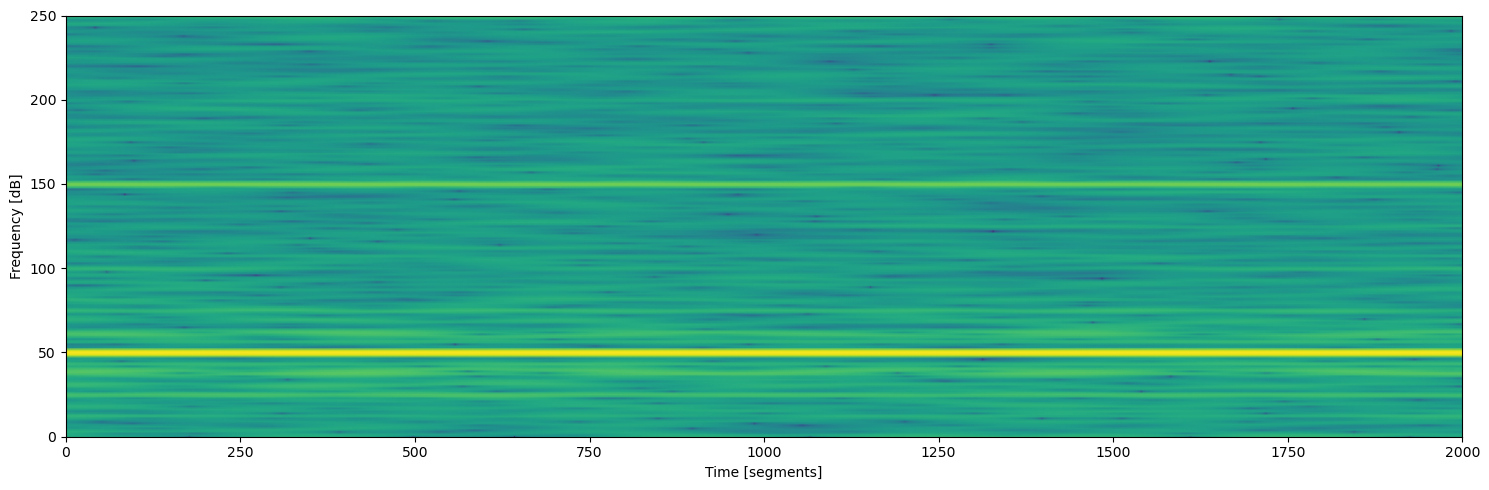

In [19]:
plot_manual_fft_as_full_spectrogram(fft_segments, freqs)

Функции сохранения спектрограммы в качестве картинки.

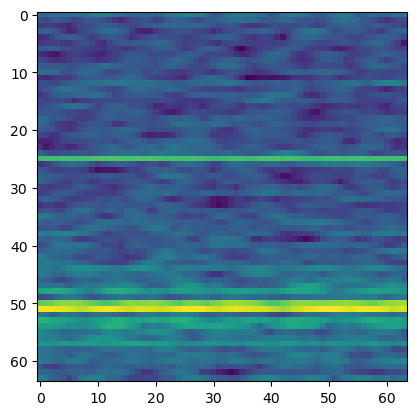

In [20]:
img = numpy_to_pillow(fft_segments.T)
plt.imshow(img)

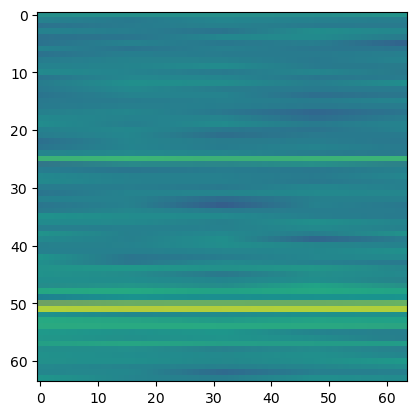

In [21]:
f, t, Sxx = signal.spectrogram(fault_signal, fs=10000, nperseg=10000, window='blackman', noverlap=20)
img = scipy_to_pillow(f, t, Sxx)
plt.imshow(img, cmap='gray')

Набираем датасет:

In [32]:
from pathlib import Path
import os
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import blackman
import shutil


def create_1d_and_2d_data(input_path: str, 
                          count_1d: int = 2000, 
                          count_2d: int = 8000, 
                          output_path: str = '../data/processed'):
    '''
    Function for collecting 1D-spectra and spectrograms

    Parameters:
    - input_path: raw data folder
    - count_1d: number of 1D-spectra for each signal type
    - count_2d: number of spectrograms for each signal type
    - output_path: processed data folder (inside output_path, a folder named 'ours_FFT' 
    for 1D-spectra and a folder named 'ours_spectrogram' for spectrograms are created)
    '''
    if os.path.isdir(output_path):
        shutil.rmtree(output_path)
    os.makedirs(output_path)
    for input_file in Path(input_path).rglob('*.txt'):
        df = read_oscilloscope_data(
            file_path=input_file,
            output_path=f'{output_path}/Anomalous.csv'
        )
        some_signal = df['Data'].to_numpy()
        some_signal_mean = np.mean(some_signal)
        some_signal -= some_signal_mean
        segments = segment_signal(some_signal, segment_length=10000, step=20, apply_window='blackman')[:count_1d]
        fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)
        os.makedirs(f"{output_path}/{input_file.name}/ours_FFT")
        os.makedirs(f"{output_path}/{input_file.name}/ours_spectrogram")
        for idx in range(len(fft_segments)):
            np.save(f"{output_path}/{input_file.name}/ours_FFT/{idx}.npy", fft_segments[idx])
        signal_samples = spectrogram_samples_manual(some_signal, 3, count_2d)
        for idx in range(len(signal_samples)):
            np.save(f"{output_path}/{input_file.name}/ours_spectrogram/{idx}_FFT.npy", signal_samples[idx][3])

create_1d_and_2d_data('../data/raw')

In [22]:
import torch
from torch.utils.data import Dataset, DataLoader


class FFTDataset(Dataset):
    '''
    Dataset class for 1D-spectra and spectrograms
    '''
    def __init__(self, files, labels):
        '''
        Parameters:
        - files: list of *.npy files
        - labels: list of class labels
        '''
        self.data = []
        self.labels = []
        for filepath in files:
            self.data.append(torch.FloatTensor(np.load(filepath)).unsqueeze(0))
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
from typing import List, Union
import random
from sklearn.model_selection import train_test_split


# для бинарной классификации обозначим "здоровый" сигнал как 0, сигналы с ошибками как 1
# и загрузим все ошибочные сигналы в датасет в равных долях 
def get_binary_dataloaders(healthy_folder: str,
                           fault_folders_list: List[str],
                           healthy_samples: Union[int, None] = None,
                           test_size: float = 0.25,
                           seed: int = 42,
                           batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for binary classification

    Parameters:
    - healty_folder: folder containing "healty" signal *.npy files 
    - fault_folders_list: list of folders containing faulty signal *.npy files
    - healthy_samples: number of samples for "healthy" signal

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = list(Path(healthy_folder).rglob('*.npy'))
    labels_list = [0 for _ in range(len(fft_list))]
    if healthy_samples is not None:
        fft_list = fft_list[:healthy_samples]
        labels_list = labels_list[:healthy_samples]
    list_part = len(fft_list) // len(fault_folders_list)
    for signal_type in fault_folders_list:
        fault_list = list(Path(signal_type).rglob('*.npy'))[:list_part]
        fft_list += fault_list
        labels_list += [1 for _ in range(len(fault_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# в мультиклассовой классификации каждый сигнал - отдельный класс
def get_multiclass_dataloaders(folders_list: List[str],
                               all_data_samples: Union[int, None] = None,
                               test_size: float = 0.25,
                               seed: int = 42,
                               batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for multiclass classification

    Parameters:
    - folders_list: list of folders containing *.npy files of different classes
    - all_data_samples: number of data samples for each class

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = []
    labels_list = []
    for i, signal_type in enumerate(folders_list):
        class_list = list(Path(signal_type).rglob('*.npy'))
        if all_data_samples is not None:
            class_list = class_list[:all_data_samples]
        fft_list += class_list
        labels_list += [i for _ in range(len(class_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [30]:
healthy_fft = '../data/processed/0702 без перекосов фаза A.txt/ours_FFT'
fault_fft = [
    '../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_FFT',
    '../data/processed/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_FFT',
    '../data/processed/21 02 дисбаланс макс обороты 100%.txt/ours_FFT',
    '../data/processed/0702  перекос фазы A ток фазы А.txt/ours_FFT',
    '../data/processed/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed/нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed/холостой ход 11 01.txt/ours_FFT'
    ]

train_loader, val_loader, test_loader = get_binary_dataloaders(healthy_fft, fault_fft)

In [31]:
class ResNet1dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm1d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv1d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm1d(out_channels),
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))


class ResNet1d(torch.nn.Module):
    def __init__(self, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=1,
                            out_channels=1,
                            kernel_size=7,
                            stride=2),
            torch.nn.BatchNorm1d(1),
            torch.nn.MaxPool1d(kernel_size=3),
            ResNet1dLayer(in_channels=1, out_channels=1, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=1, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=2, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=2, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=4, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet1dLayer(in_channels=4, out_channels=8, kernel_size_1=3, kernel_size_2=5),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features=8, out_features=out_features),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(self.seq(x).squeeze()).squeeze()

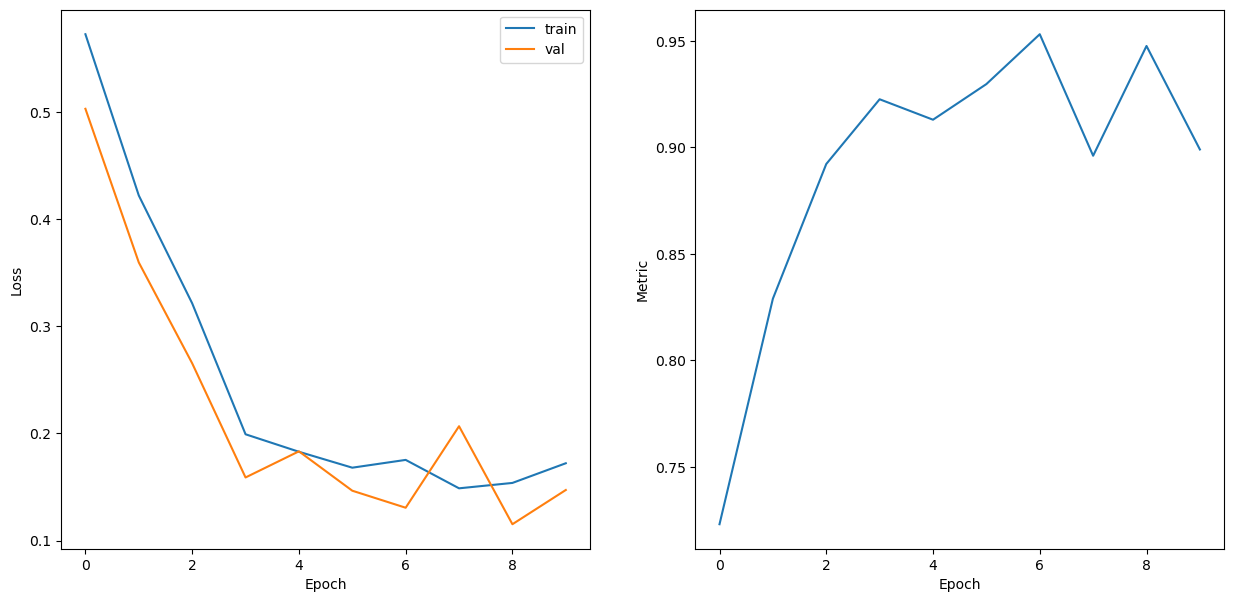

In [32]:
import IPython
import IPython.display
from sklearn.metrics import f1_score


EPOCHS = 10
resnet_1d = ResNet1d().to(device=device)
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.BCELoss()


# mode - parameter that determines the method of calculating the loss and the metric
# average - parameter that determines the method of averaging the metric
def train(model,
          train_loader,
          val_loader,
          epochs,
          criterion,
          dtype,
          optimizer,
          metric,
          filename,
          mode='binary', 
          average='binary'): 
    best_val_loss = np.inf
    epoch_train = []
    epoch_val = []
    epoch_metric = []
    for epoch in range(epochs):
        model.train()
        train_loss = []
        val_loss = []
        val_metric = []
        for x, y in train_loader:
            optimizer.zero_grad()
            out = model(x.to(device=device))
            loss = criterion(out, y.to(device=device, dtype=dtype))
            train_loss.append(loss.item())
            loss.backward()
            optimizer.step()
        epoch_train.append(sum(train_loss) / len(train_loader))
        model.eval()
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x.to(device=device))
                loss = criterion(out, y.to(device=device, dtype=dtype))
                val_loss.append(loss.item())
                if mode == 'binary':
                    val_metric.append(metric(y, out.detach().cpu() > 0.5, average=average))
                else:
                    val_metric.append(metric(y, torch.argmax(out.detach().cpu(), dim=1), average=average))
        mean_val_loss = sum(val_loss) / len(val_loader)
        if mean_val_loss < best_val_loss:
            torch.save(model.state_dict(), filename)
        epoch_val.append(mean_val_loss)
        epoch_metric.append(sum(val_metric) / len(val_loader))
        IPython.display.clear_output()
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
        ax[0].plot(list(range(0, epoch+1)), epoch_train, label='train')
        ax[0].plot(list(range(0, epoch+1)), epoch_val, label='val')
        ax[0].legend()
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Loss')
        ax[1].plot(list(range(0, epoch+1)), epoch_metric)
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Metric')
        plt.show()


train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, torch.float, optimizer, f1_score, 'best_1d.pt')

F1 = 0.9044526262429177


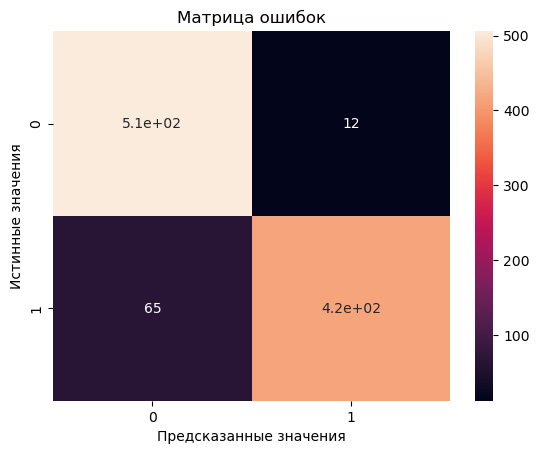

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


best_resnet_1d = ResNet1d().to(device=device)
best_resnet_1d.load_state_dict(torch.load('best_1d.pt'))


# mode - parameter that determines the method of calculating the metric
# average - parameter that determines the method of averaging the metric
def mean_metric_on_test(model, metric, test_loader, mode='binary', average='binary'):
    metrics = []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            if mode == 'binary':
                metrics.append(metric(y, out.detach().cpu() > 0.5, average=average))
            else:
                metrics.append(metric(y, torch.argmax(out.detach().cpu(), dim=1), average=average))
    return sum(metrics) / len(test_loader)


# mode - parameter that determines the method of calculating the metric
def get_confusion_matrix(model, test_loader, mode='binary'):
    y_true = []
    y_pred = []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            y_true += y.tolist()
            out = model(x.to(device=device))
            if mode == 'binary':
                y_pred += (out.detach().cpu() > 0.5).tolist()
            else:
                y_pred += torch.argmax(out.detach().cpu(), dim=1).tolist()
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True)
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.title('Матрица ошибок')
    plt.show()


print(f'F1 = {mean_metric_on_test(best_resnet_1d, f1_score, test_loader)}')
get_confusion_matrix(best_resnet_1d, test_loader)

In [34]:
healthy_fft = '../data/processed/0702 без перекосов фаза A.txt/ours_spectrogram'
fault_fft = [
    '../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed/холостой ход 11 01.txt/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_binary_dataloaders(healthy_fft, fault_fft)

In [35]:
class ResNet2dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(out_channels),
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))


class ResNet2d(torch.nn.Module):
    def __init__(self, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1,
                            out_channels=1,
                            kernel_size=7,
                            stride=2),
            torch.nn.BatchNorm2d(1),
            torch.nn.MaxPool2d(kernel_size=3),
            ResNet2dLayer(in_channels=1, out_channels=1, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=1, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=2, out_channels=2, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=2, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=4, out_channels=4, kernel_size_1=3, kernel_size_2=5),
            ResNet2dLayer(in_channels=4, out_channels=8, kernel_size_1=3, kernel_size_2=5),
            torch.nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(in_features=8, out_features=out_features),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(self.seq(x).squeeze()).squeeze()

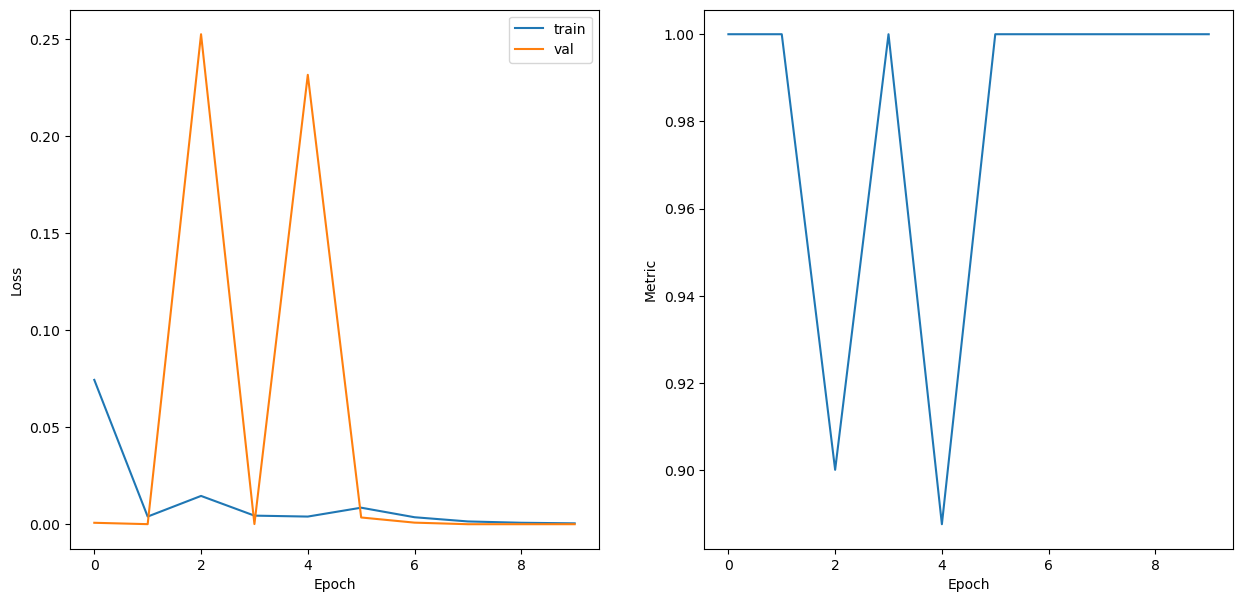

In [36]:
EPOCHS = 10
resnet_2d = ResNet2d().to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters())
criterion = torch.nn.BCELoss()

train(resnet_2d, train_loader, val_loader, EPOCHS, criterion, torch.float, optimizer, f1_score, 'best_2d.pt')

F1 = 1.0


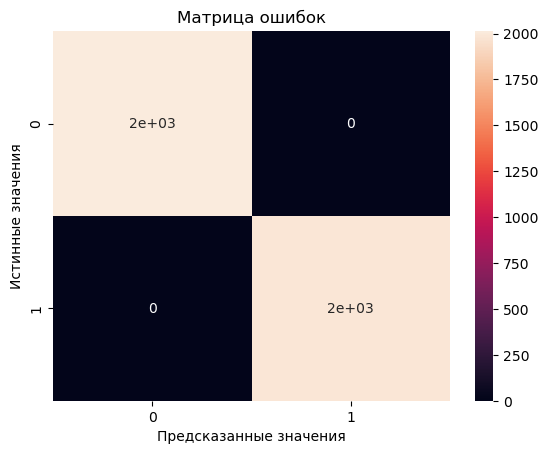

In [37]:
best_resnet_2d = ResNet2d().to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d.pt'))

print(f'F1 = {mean_metric_on_test(best_resnet_2d, f1_score, test_loader)}')
get_confusion_matrix(best_resnet_2d, test_loader)

Попробуем многоклассовую классификацию.

In [38]:
signals_list = [
    '../data/processed/0702 без перекосов фаза A.txt/ours_FFT',
    '../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_FFT',
    '../data/processed/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_FFT',
    '../data/processed/21 02 дисбаланс макс обороты 100%.txt/ours_FFT',
    '../data/processed/0702  перекос фазы A ток фазы А.txt/ours_FFT',
    '../data/processed/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed/нагрузка 100% 11 01.txt/ours_FFT',
    '../data/processed/холостой ход 11 01.txt/ours_FFT'
    ]

train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list)

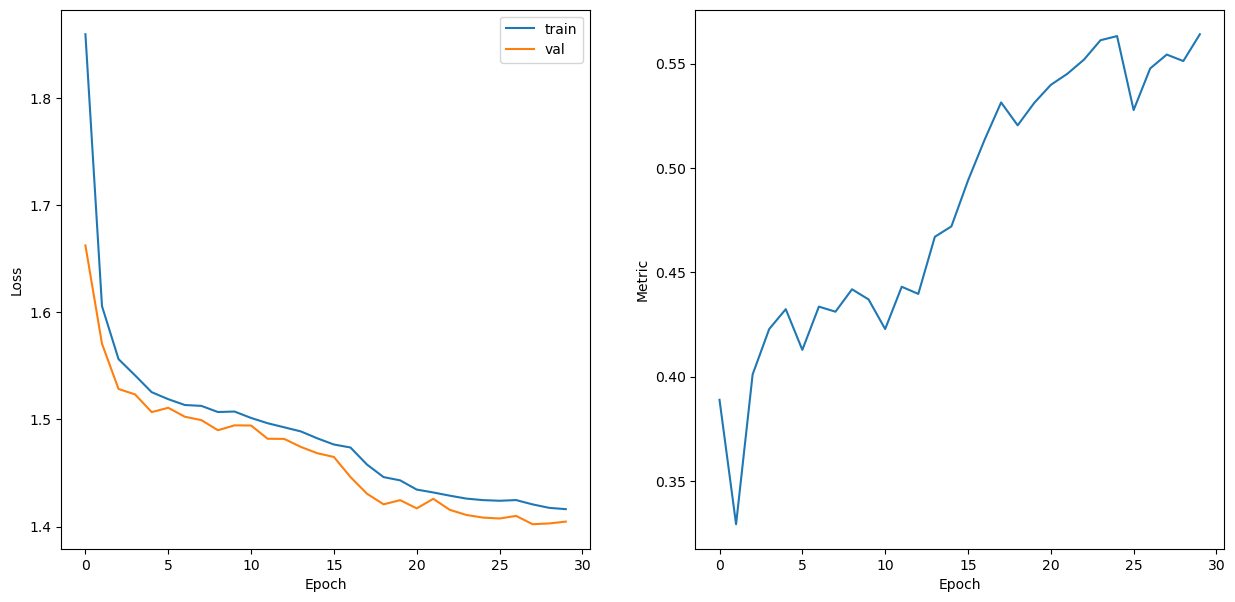

In [39]:
EPOCHS = 30
resnet_1d = ResNet1d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_1d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_1d, train_loader, val_loader, EPOCHS, criterion, torch.long, optimizer, f1_score, 'best_1d_multiclass.pt', mode='multi', average='micro')

F1 = 0.5535


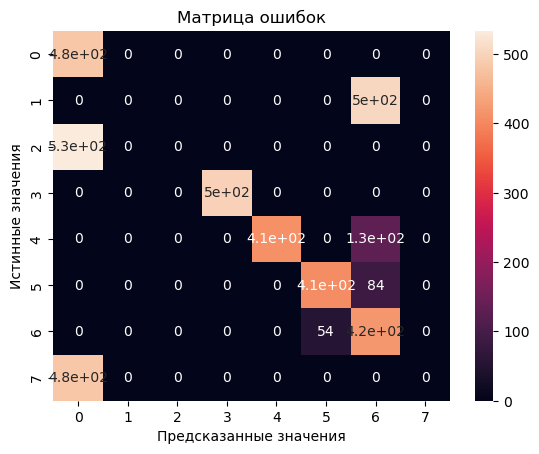

In [40]:
best_resnet_1d = ResNet1d(out_features=8).to(device=device)
best_resnet_1d.load_state_dict(torch.load('best_1d_multiclass.pt'))

mean_metric = mean_metric_on_test(best_resnet_1d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_1d, test_loader, mode='multi')

In [41]:
signals_list = [
    '../data/processed/0702 без перекосов фаза A.txt/ours_spectrogram',
    '../data/processed/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed/холостой ход 11 01.txt/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list, all_data_samples=2000)

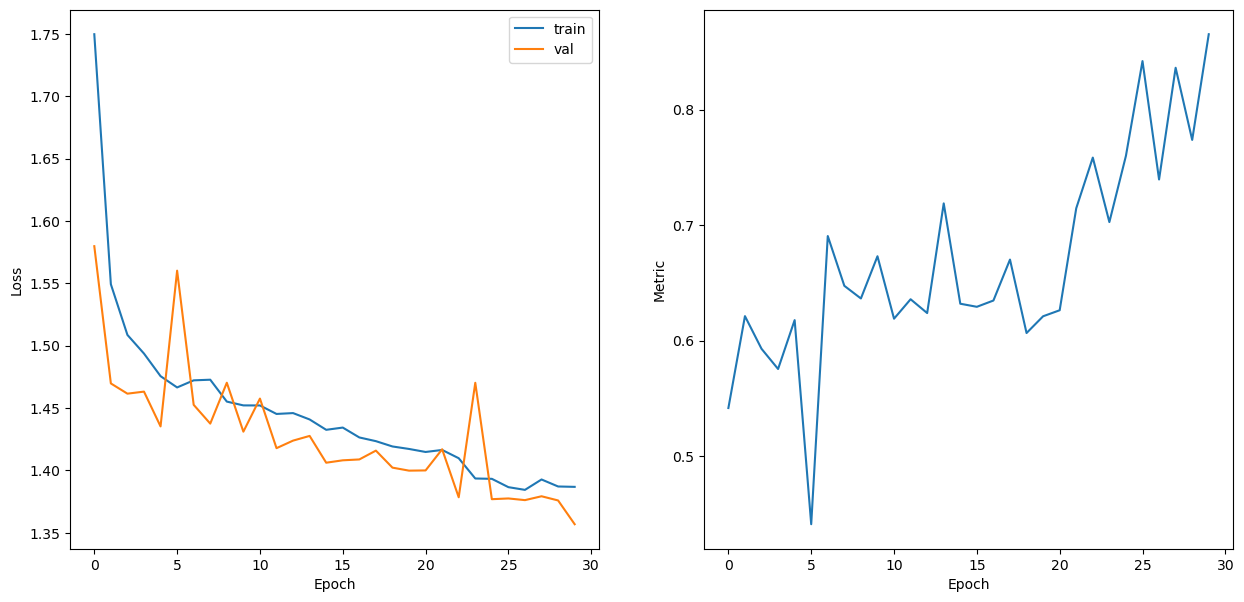

In [42]:
EPOCHS = 30
resnet_2d = ResNet2d(out_features=8).to(device=device)
optimizer = torch.optim.Adam(resnet_2d.parameters())
criterion = torch.nn.CrossEntropyLoss()

train(resnet_2d, train_loader, val_loader, EPOCHS, criterion, torch.long, optimizer, f1_score, 'best_2d_multiclass.pt', mode='multi', average='micro')

F1 = 0.8645


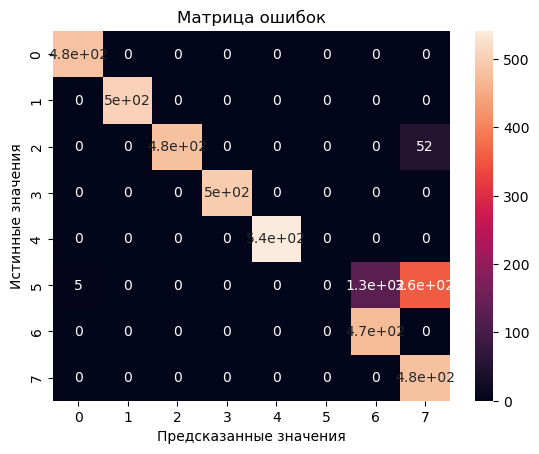

In [43]:
best_resnet_2d = ResNet2d(out_features=8).to(device=device)
best_resnet_2d.load_state_dict(torch.load('best_2d_multiclass.pt'))

mean_metric = mean_metric_on_test(best_resnet_2d, f1_score, test_loader, mode='multi', average='micro')
print(f'F1 = {mean_metric}')
get_confusion_matrix(best_resnet_2d, test_loader, mode='multi')